# Celestial Mechanics: Kepler Orbit Regime Classification

Classify low- and high-eccentricity Keplerian orbits from sparse radial measurements using quantum kernel and quantum reservoir classifiers.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** Identify whether an orbit is nearly circular or highly eccentric from a few radius samples over true anomaly.

**Explicit variables.** `eccentricity` controls orbit shape, `anomaly_grid` gives measurement angles, and `qkc_pred` contains quantum-kernel orbit-regime predictions.

**Quantum advantage context.** Quantum kernels and reservoir features can encode nonlinear geometric patterns in small scientific datasets. This notebook compares both quantum estimators with logistic regression.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from qml import (
    QuantumGaussianProcessRegressor,
    QuantumKernel,
    QuantumKernelClassifier,
    QuantumKernelPCA,
    QuantumKernelRegressor,
    QuantumOneClassClassifier,
    QuantumReservoirClassifier,
    QuantumReservoirFeatures,
    QuantumReservoirRegressor,
    TrainableQuantumKernelRegressor,
)
from qml.reporting import print_section


## Domain simulator

The notebook samples normalized radial profiles from the Kepler conic equation `r = a(1-e^2)/(1+e cos(theta))` and labels each profile by eccentricity regime.

In [2]:
def kepler_radius(eccentricity, anomaly_grid, *, semi_major_axis=1.0):
    return semi_major_axis * (1.0 - eccentricity**2) / (1.0 + eccentricity * np.cos(anomaly_grid))

rng = np.random.default_rng(811)
n_samples = 44
anomaly_grid = np.linspace(0.0, 2.0 * np.pi, 6, endpoint=False)
eccentricity = rng.uniform(0.02, 0.82, size=n_samples)
semi_major_axis = rng.uniform(0.85, 1.15, size=n_samples)
radius_profiles = np.asarray([
    kepler_radius(e, anomaly_grid, semi_major_axis=a) for e, a in zip(eccentricity, semi_major_axis)
])
radius_profiles = radius_profiles / radius_profiles.mean(axis=1, keepdims=True)
radius_profiles += rng.normal(0.0, 0.015, size=radius_profiles.shape)
regime = (eccentricity >= 0.42).astype(int)

x_train, x_test, y_train, y_test, e_train, e_test = train_test_split(
    radius_profiles, regime, eccentricity, test_size=0.3, random_state=811, stratify=regime
)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print_section(
    "Dataset",
    [
        ("Problem", "Kepler orbit eccentricity regime classification"),
        ("Samples", n_samples),
        ("Features", [f"r(theta={theta:.2f})" for theta in anomaly_grid]),
        ("Classes", {0: "low eccentricity", 1: "high eccentricity"}),
    ],
)


Dataset
+----------+--------------------------------------------------------------------------------------------+
| Metric   | Value                                                                                      |
+----------+--------------------------------------------------------------------------------------------+
| Problem  | Kepler orbit eccentricity regime classification                                            |
| Samples  | 44                                                                                         |
| Features | [r(theta=0.00), r(theta=1.05), r(theta=2.09), r(theta=3.14), r(theta=4.19), r(theta=5.24)] |
| Classes  | {0: 'low eccentricity', 1: 'high eccentricity'}                                            |
+----------+--------------------------------------------------------------------------------------------+



## System visualization

A direct plot of the simulated physical or mathematical system before fitting any machine-learning model.

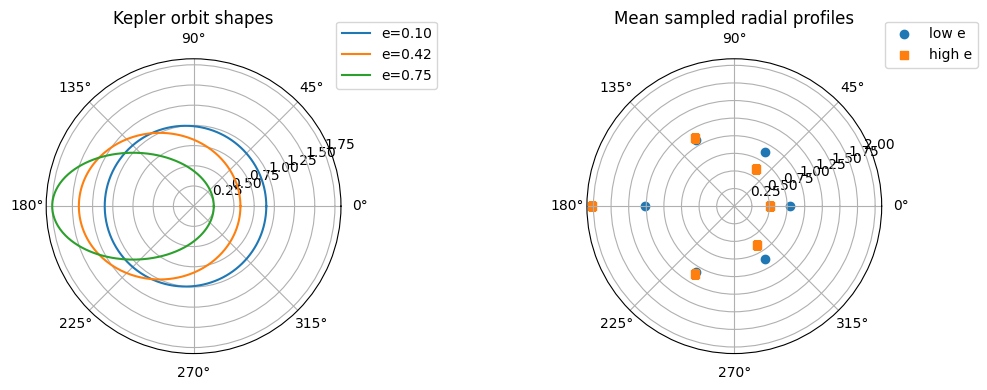

In [3]:
theta_grid = np.linspace(0.0, 2.0 * np.pi, 240)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), subplot_kw={"projection": "polar"})
for e in [0.1, 0.42, 0.75]:
    axes[0].plot(theta_grid, kepler_radius(e, theta_grid), label=f"e={e:.2f}")
axes[0].set_title("Kepler orbit shapes")
axes[0].legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
for label, marker in [(0, "o"), (1, "s")]:
    idx = np.where(regime == label)[0][:6]
    axes[1].scatter(anomaly_grid, radius_profiles[idx].mean(axis=0), marker=marker, label="low e" if label == 0 else "high e")
axes[1].set_title("Mean sampled radial profiles")
axes[1].legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()


## Package-client classification models

In [4]:
qkc = QuantumKernelClassifier(QuantumKernel(embedding="iqp", seed=811))
qkc.fit(x_train, y_train)
qkc_pred = qkc.predict(x_test)

reservoir = QuantumReservoirClassifier(
    QuantumReservoirFeatures(n_qubits=6, n_layers=2, seed=812),
    c=1.5,
    max_iter=1000,
)
reservoir.fit(x_train, y_train)
reservoir_pred = reservoir.predict(x_test)

logistic = LogisticRegression(max_iter=1000)
logistic.fit(x_train, y_train)
logistic_pred = logistic.predict(x_test)

results = {
    "quantum_kernel_accuracy": accuracy_score(y_test, qkc_pred),
    "quantum_reservoir_accuracy": accuracy_score(y_test, reservoir_pred),
    "logistic_accuracy": accuracy_score(y_test, logistic_pred),
}

print_section(
    "Results",
    [
        ("Quantum kernel accuracy", results["quantum_kernel_accuracy"]),
        ("Quantum reservoir accuracy", results["quantum_reservoir_accuracy"]),
        ("Logistic accuracy", results["logistic_accuracy"]),
    ],
)


Results
+----------------------------+----------+
| Metric                     | Value    |
+----------------------------+----------+
| Quantum kernel accuracy    | 1        |
| Quantum reservoir accuracy | 0.857143 |
| Logistic accuracy          | 1        |
+----------------------------+----------+



## Plots

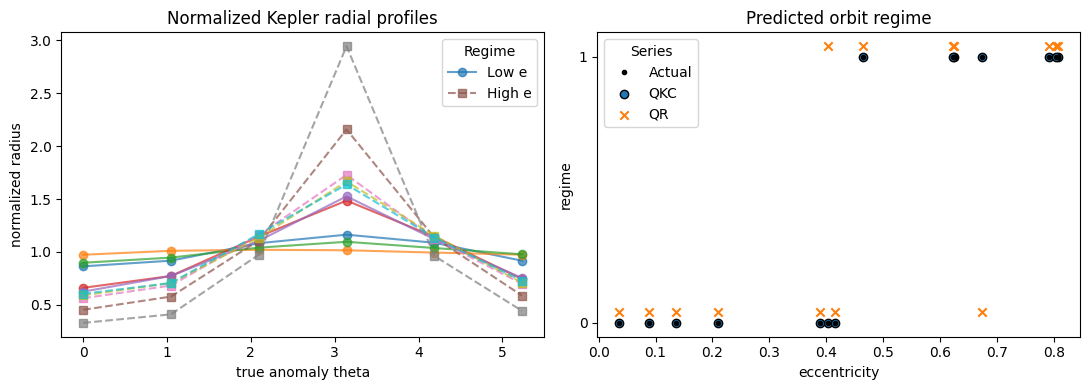

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), subplot_kw={"projection": None})
for label, style in [(0, "o-"), (1, "s--")]:
    idx = np.where(regime == label)[0][:5]
    for pos, sample_idx in enumerate(idx):
        axes[0].plot(
            anomaly_grid,
            radius_profiles[sample_idx],
            style,
            alpha=0.7,
            label=("Low e" if label == 0 else "High e") if pos == 0 else None,
        )
axes[0].set_title("Normalized Kepler radial profiles")
axes[0].set_xlabel("true anomaly theta")
axes[0].set_ylabel("normalized radius")
axes[0].legend(title="Regime")

order = np.argsort(e_test)
axes[1].plot(e_test[order], y_test[order], "k.", label="Actual")
axes[1].scatter(e_test, qkc_pred, label="QKC", edgecolor="black")
axes[1].scatter(e_test, reservoir_pred + 0.04, marker="x", label="QR")
axes[1].set_yticks([0, 1])
axes[1].set_title("Predicted orbit regime")
axes[1].set_xlabel("eccentricity")
axes[1].set_ylabel("regime")
axes[1].legend(title="Series")
plt.tight_layout()
plt.show()


## Validation block

In [6]:
validation = {
    "dataset": {
        "problem": "kepler_orbit_regime_classification",
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "feature_count": int(x_train.shape[1]),
    },
    "results": results,
    "sample_predictions": [
        {"eccentricity": float(e), "actual_regime": int(a), "quantum_kernel_regime": int(p)}
        for e, a, p in zip(e_test[:6], y_test[:6], qkc_pred[:6])
    ],
    "passed": bool(
        np.isfinite(qkc_pred).all()
        and results["quantum_kernel_accuracy"] >= 0.75
        and results["quantum_reservoir_accuracy"] >= 0.70
    ),
}

print("Validation")
print_section("Dataset", validation["dataset"].items())
print_section("Results", validation["results"].items())
print_section("Sample predictions", validation["sample_predictions"][:5])
print_section("Passed", [("passed", validation["passed"])])


Validation
Dataset
+---------------+------------------------------------+
| Metric        | Value                              |
+---------------+------------------------------------+
| problem       | kepler_orbit_regime_classification |
| n_train       | 30                                 |
| n_test        | 14                                 |
| feature_count | 6                                  |
+---------------+------------------------------------+

Results
+----------------------------+----------+
| Metric                     | Value    |
+----------------------------+----------+
| quantum_kernel_accuracy    | 1        |
| quantum_reservoir_accuracy | 0.857143 |
| logistic_accuracy          | 1        |
+----------------------------+----------+

Sample predictions
+--------------+---------------+-----------------------+
| eccentricity | actual_regime | quantum_kernel_regime |
+--------------+---------------+-----------------------+
| 0.672496     | 1             | 1             